# Package requirements

In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Print versions of the packages being used
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("matplotlib version:", matplotlib.__version__)

pandas version: 2.2.3
numpy version: 1.26.4
matplotlib version: 3.9.2


# For the Figure 2e

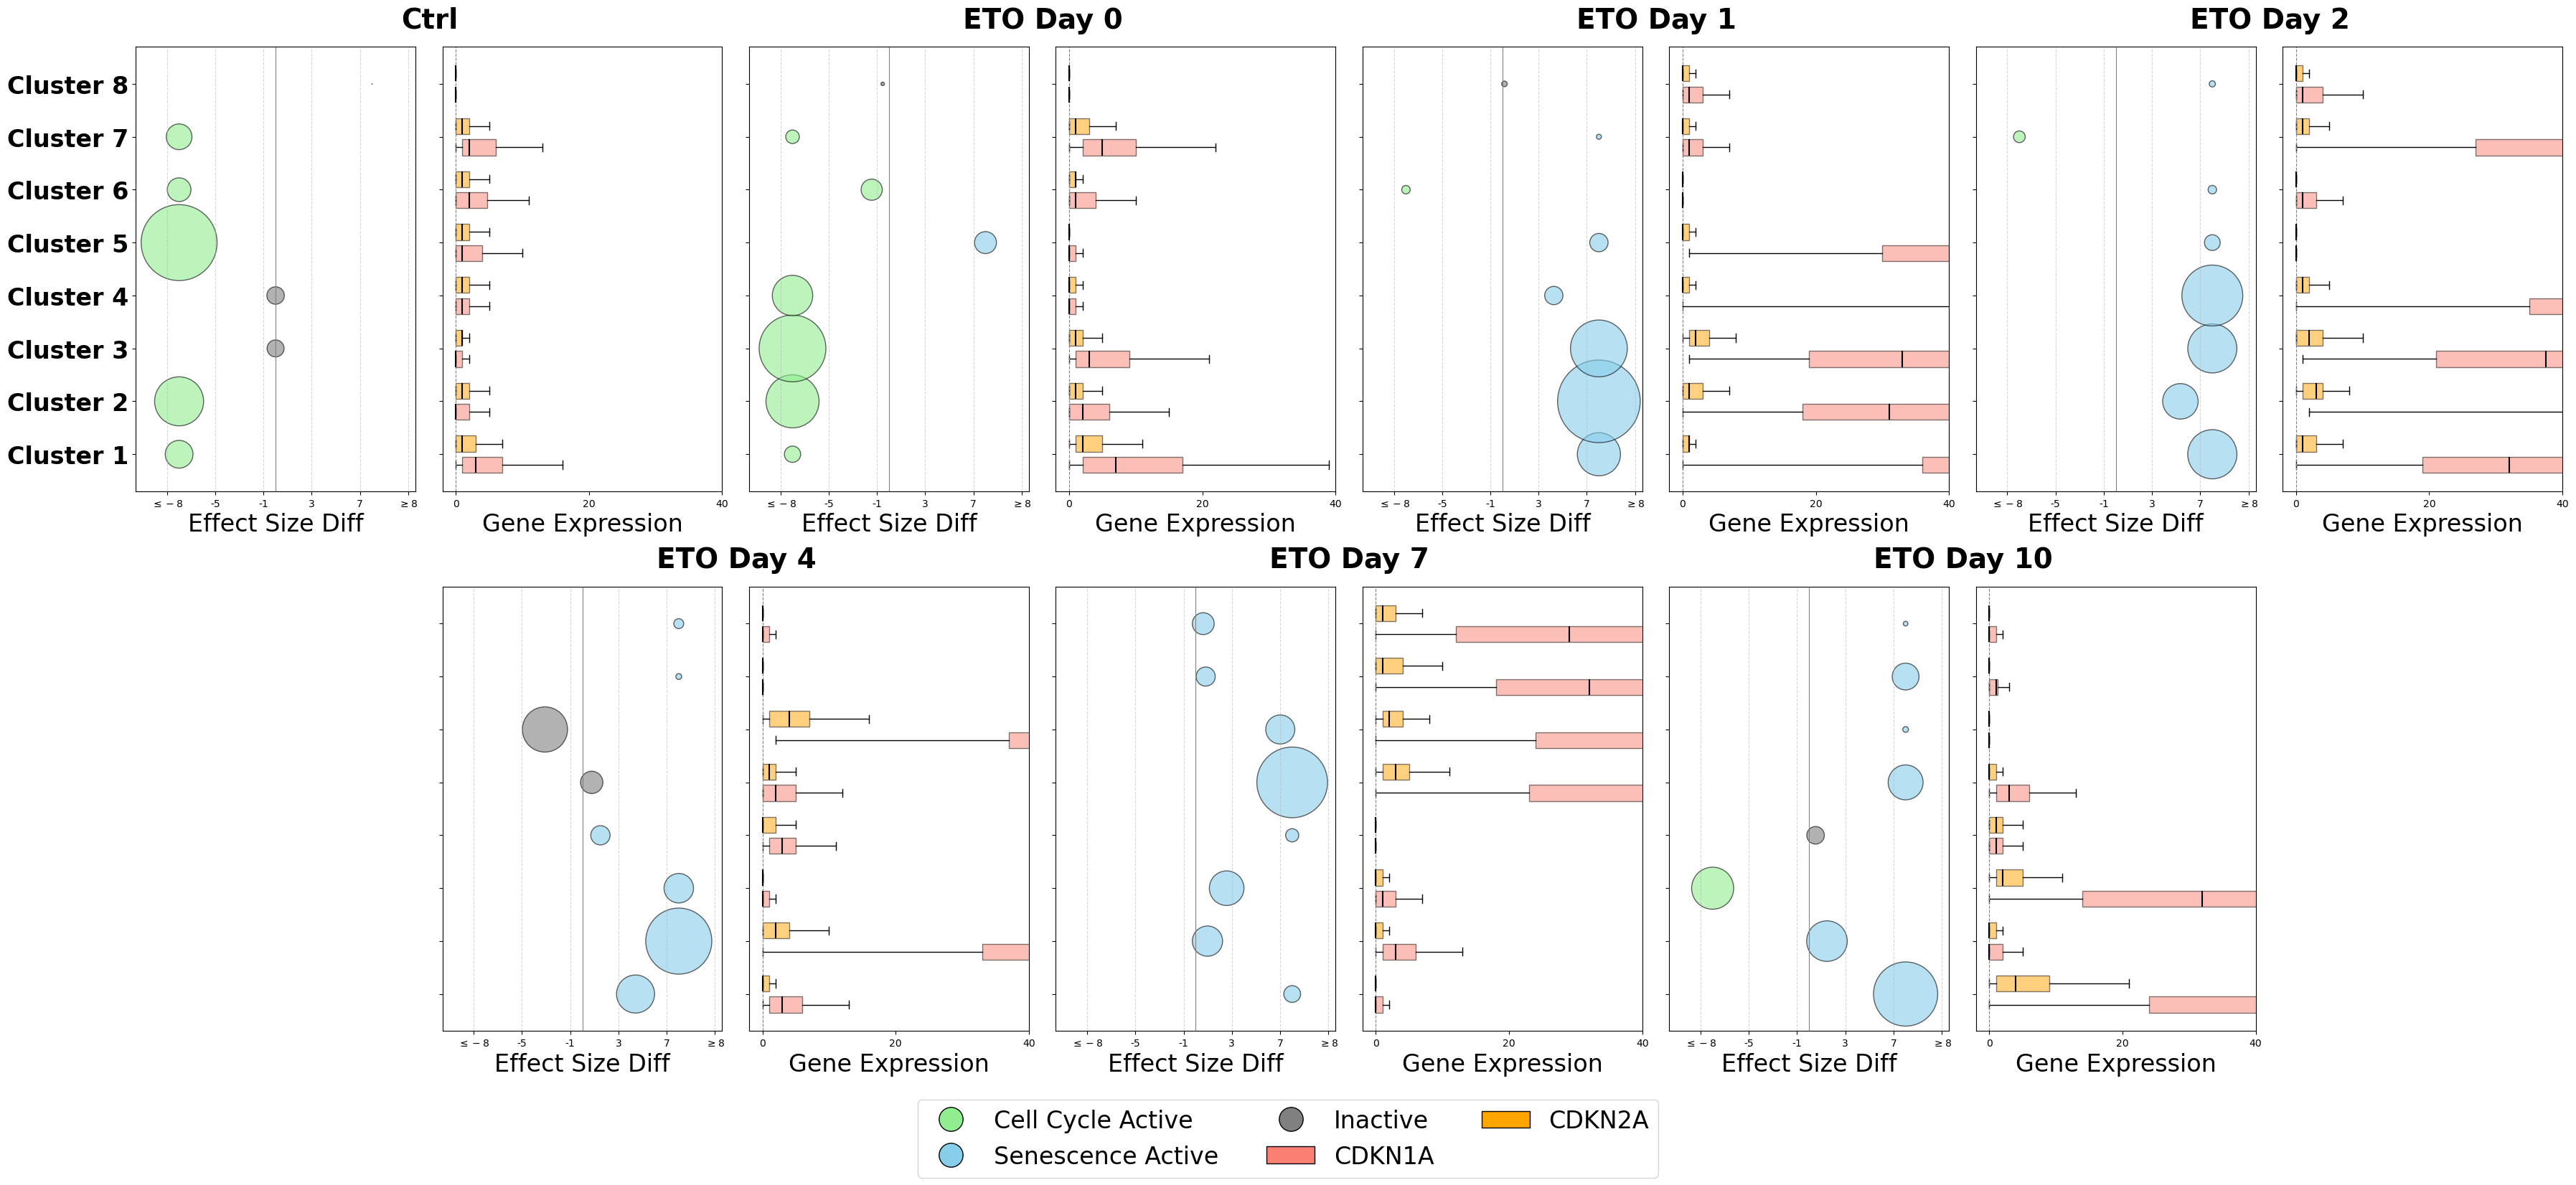

In [2]:
# Assume final_df_final and expression_melted are defined and pre-processed
# Also assume geneA = 'CDKN1A' and geneB = 'CDKN2A'
final_df = pd.read_csv('Results/Senescence/final_analysis.csv')
expression_melted = pd.read_csv('Results/Senescence/expresstion_melted.csv')

geneA = 'CDKN1A'
geneB = 'CDKN2A'

unique_groups = final_df['Group'].unique()
clusters = sorted(final_df['Cluster'].unique())

R = 0.2
SCALING_FACTOR = 1000
offset = 0.2

num_groups = len(unique_groups)
assert num_groups == 7, "This code is designed for exactly 7 groups."

fig, axs = plt.subplots(nrows=2, ncols=8, sharey=True, figsize=(36, 16))
plt.subplots_adjust(wspace=0.02, hspace=0.1)

# Positions for groups:
# Top row: 4 groups across 8 columns
top_row_positions = [
    (0, (0,1)),  # Group 0: columns 0 & 1
    (0, (2,3)),  # Group 1: columns 2 & 3
    (0, (4,5)),  # Group 2: columns 4 & 5
    (0, (6,7))   # Group 3: columns 6 & 7
]

# Bottom row: 3 groups centered in the middle columns
bottom_row_positions = [
    (1, (1,2)),  # Group 4: columns 1 & 2
    (1, (3,4)),  # Group 5: columns 3 & 4
    (1, (5,6))   # Group 6: columns 5 & 6
]

positions = top_row_positions + bottom_row_positions

# We will turn off the empty subplots at second row, first and last column
axs[1,0].axis('off')
axs[1,7].axis('off')

# Legend elements: The order is 3 dots first, then 2 patches.
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Cell Cycle Active',
           markerfacecolor='lightgreen', markersize=24, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Senescence Active',
           markerfacecolor='skyblue', markersize=24, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Inactive',
           markerfacecolor='gray', markersize=24, markeredgecolor='black'),
    Patch(facecolor='salmon', edgecolor='black', label=geneA),
    Patch(facecolor='orange', edgecolor='black', label=geneB)
]

for i, group in enumerate(unique_groups):
    group_df = final_df[final_df['Group'] == group]
    M = group_df['Number of cells'].sum()

    # Prepare bubble plot data
    z_diff_list = []
    num_cells_list = []
    colors = []
    clusters_present = []

    for cluster in clusters:
        cluster_row = group_df[group_df['Cluster'] == cluster]
        if cluster_row.empty:
            z_diff = 0
            num_cells = 0
            color = 'gray'
        else:
            z_diff = cluster_row.iloc[0]['Z-Score Difference (Senescence - Cell Cycle)']
            num_cells = cluster_row.iloc[0]['Number of cells']
            color = cluster_row.iloc[0]['Color']

        # Cap z_diff
        if z_diff >= 8:
            z_diff_capped = 8
        elif z_diff <= -8:
            z_diff_capped = -8
        else:
            z_diff_capped = z_diff

        z_diff_list.append(z_diff_capped)
        num_cells_list.append(num_cells)
        colors.append(color)
        clusters_present.append(cluster)

    relative_sizes = [(n / M) * R for n in num_cells_list]
    scatter_sizes = [(size * SCALING_FACTOR) ** 2.1 for size in relative_sizes]

    # Prepare gene expression data for boxplots
    subset_expr = expression_melted[expression_melted['Group'] == group]
    geneA_data = []
    geneB_data = []
    for cluster in clusters_present:
        cluster_expr = subset_expr[subset_expr['Cluster_ID'] == cluster]
        geneA_values = cluster_expr[cluster_expr['Gene'] == geneA]['Expression'].values
        geneB_values = cluster_expr[cluster_expr['Gene'] == geneB]['Expression'].values
        geneA_data.append(geneA_values)
        geneB_data.append(geneB_values)

    row, (col_bubble1, col_bubble2) = positions[i]
    ax_bubble = axs[row, col_bubble1]
    ax_box = axs[row, col_bubble2]

    # Bubble plot
    scatter = ax_bubble.scatter(
        z_diff_list,
        clusters_present,
        s=scatter_sizes,
        c=colors,
        alpha=0.6,
        edgecolors='black'
    )

    # Set x-ticks for bubble plot
    fixed_xticks = list(range(-13, 13, 4))
    fixed_xlabels = []
    for xval in fixed_xticks:
        if xval >= 8:
            label = r'$\geq 8$'
        elif xval <= -8:
            label = r'$\leq -8$'
        else:
            label = f'{xval}'
        fixed_xlabels.append(label)

    ax_bubble.set_xticks(fixed_xticks)
    ax_bubble.set_xticklabels(fixed_xlabels)
    ax_bubble.set_xlim(-11.6, 11.6)
    ax_bubble.axvline(x=0, color='grey', linewidth=0.8)
    ax_bubble.grid(True, linestyle='--', alpha=0.5, axis='x')

    # Show y-labels only on the first bubble plot of top row and first bubble plot of bottom row
    if i == 0 or i == 4:
        ax_bubble.set_yticks(clusters_present)
        ax_bubble.set_yticklabels([f'Cluster {c}' for c in clusters_present], fontsize=24, fontweight='bold')
    else:
        ax_bubble.yaxis.set_tick_params(labelleft=False)

    ax_bubble.set_xlabel('Effect Size Diff', fontsize=24)
    ax_bubble.set_title(f'{group}', fontsize=28, pad=10, y=1.02, x=1.05, fontweight='bold')

    # Boxplots
    ax_box.boxplot(
        geneA_data, 
        vert=False, 
        positions=[c - offset for c in clusters_present],
        patch_artist=True,
        boxprops=dict(facecolor='salmon', alpha=0.5, edgecolor='black'),
        medianprops=dict(color='black', linewidth=1.5),
        widths=0.3,
        showfliers=False
    )
    ax_box.boxplot(
        geneB_data, 
        vert=False, 
        positions=[c + offset for c in clusters_present],
        patch_artist=True,
        boxprops=dict(facecolor='orange', alpha=0.5, edgecolor='black'),
        medianprops=dict(color='black', linewidth=1.5),
        widths=0.3,
        showfliers=False
    )

    ax_box.set_xlim(-2, 40)
    ax_box.set_xticks([0, 20, 40])
    ax_box.axvline(x=0, color='grey', linewidth=0.8, linestyle='--')
    ax_box.set_xlabel('Gene Expression', fontsize=24)
    ax_box.xaxis.set_label_position('bottom')
    ax_box.xaxis.tick_bottom()
    ax_box.yaxis.set_tick_params(labelleft=False)

fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.09), ncol=3, fontsize=24)

ax_bubble.set_yticks(clusters_present)
ax_bubble.set_yticklabels([f'Cluster {c}' for c in clusters_present])

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()